# Publication Figures: Eterna OpenKnot Benchmark Results

This notebook generates all figures for the **Eterna OpenKnot Benchmark** results.

### Round 3 (100-mer targets) - Figure 2A-F
1. **OpenKnot Score stripplots**: Individual design scores for natural (P01-P10) and synthetic (P11-P20) puzzles
2. **Success rate barplots**: Overall success rates by method
3. **Reactivity heatmaps**: Experimental SHAPE profiles for P03 (ZMP Riboswitch) and P11 (PN.v282)
4. **Structure visualizations**: Wild-type vs gRNAde design comparisons with scores

### Round 4 (240-mer targets) - Supplementary Figure 1
5. **OpenKnot Score stripplots**: Extended-length puzzles (Q01-Q20)
6. **Success rate barplots**: Performance on longer, more challenging targets


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import re

# Load Round 3 Data (100-mer Puzzles)

In [12]:
# Read the metadata CSV file into a DataFrame
df_metadata = pd.read_csv("metadata_7a.csv")

# Read the CSV file into a DataFrame
df = pd.read_csv('OpenKnotBench_data.v3.1.0.csv')

# Keep only specified round 
df = df[df["round"] == 3]

# for the df method column, if the method is gRNAde2, extract the mode from the id column and append it to the method's string, i.e. gRNAde2_2d or gRNAde2_3d
# df["method"] = df.apply(lambda x: x["method"] + "_" + x["id"].split("mode=")[1].split("_")[0] if x["method"] == "gRNAde2" else x["method"], axis=1)

# Only keep the following methods: gRNAde2_2d, gRNAde2_3d, Rosetta, Eterna, WT
df = df[df["method"].isin(["WT", "Rosetta", "Eterna", "gRNAde2_2d", "gRNAde2_3d", "gRNAde2", "MPNN-fixbb", "MPNN-RFdiff"])]

# Raname methods for visualization and analysis
df["method"] = df["method"].replace({
    "WT": "WT sequence\n(baseline)",
    "Eterna": "Expert human\n(manual)",
    "gRNAde2_2d": "gRNAde 2D",
    "gRNAde2_3d": "gRNAde 3D",
    "gRNAde2": "gRNAde",
    "MPNN-RFdiff": "RFDiffusion",
    "MPNN-fixbb": "MPNN"
})

df

,id,sequence,experiment_type,dataset_name,reads,signal_to_noise,SN_filter,round,puzzle,method,...,reactivity_error_0298,reactivity_error_0299,reactivity_error_0300,reactivity_error_0301,reactivity_error_0302,reactivity_error_0303,reactivity_error_0304,reactivity_error_0305,reactivity_error_0306,reactivity_error_0307
17306,13620828_afavor_puzzle=Thermotoga_petrophila_f...,GGGAACGACUCGAGUAGAGUCGAAAAGGAACUUGUUCGCAAGUUCC...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,2672,3.528,1,3,P01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17307,13620828_afavor_puzzle=Thermotoga_petrophila_f...,GGGAACGACUCGAGUAGAGUCGAAAAGGAACUUGUUCGCAAGUUCC...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,17201,12.164,1,3,P01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17308,13620828_afavor_puzzle=Thermotoga_petrophila_f...,GGGAACGACUCGAGUAGAGUCGAAAAGGAACUUGUUCGCAAGUUCC...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,22641,12.691,1,3,P01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17309,13620828_afavor_puzzle=Thermotoga_petrophila_f...,GGGAACGACUCGAGUAGAGUCGAAAAGGAACUUGUUCGCAAGUUCC...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,17819,13.964,1,3,P01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17310,13620828_afavor_puzzle=Thermotoga_petrophila_f...,GGGAACGACUCGAGUAGAGUCGAAAAGGAACUUGUUCGCAAGUUCC...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,135189,38.560,1,3,P01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26419,KissingKissing_multiloops_x5_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAGGACGACAGUCUGCUUGCAG...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,45975,17.244,1,3,P20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26420,KissingKissing_multiloops_x4_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAGGACGACAGUCUGCUUGCAG...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,149130,32.639,1,3,P20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26421,KissingKissing_multiloops_x2_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAGGACGACAGUCUGCUUGCAG...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,15760,9.471,1,3,P20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26422,KissingKissing_multiloops_x1_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAGGACGACAGUCUGCUUGCAG...,2A3_MaP,NovaSeq_2025-01-14_WK_OK7a_RNN,79772,24.601,1,3,P20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Load Round 4 Data (240-mer Puzzles)

In [13]:
# Read the metadata CSV file into a DataFrame
df_metadata2 = pd.read_csv("metadata_7b.csv")

# Read the CSV file into a DataFrame
df2 = pd.read_csv('OpenKnotBench_data.v3.1.0.csv')

# Keep only specified round 
df2 = df2[df2["round"] == 4]

# Only keep the following methods: gRNAde2_2d, gRNAde2_3d, Rosetta, Eterna, WT
df2 = df2[df2["method"].isin(["WT", "Rosetta", "Eterna", "gRNAde2_2d", "gRNAde2_3d", "gRNAde2", "MPNN-fixbb", "MPNN-RFdiff"])]

# Raname methods:
# WT -> WT sequence baseline
# Eterna -> Expert human
df2["method"] = df2["method"].replace({
    "WT": "WT sequence\n(baseline)",
    "Eterna": "Expert human\n(manual)",
    "gRNAde2_2d": "gRNAde 2D",
    "gRNAde2_3d": "gRNAde 3D",
    "gRNAde2": "gRNAde",
    "MPNN-RFdiff": "RFDiffusion",
    "MPNN-fixbb": "MPNN"
})

df2

,id,sequence,experiment_type,dataset_name,reads,signal_to_noise,SN_filter,round,puzzle,method,...,reactivity_error_0298,reactivity_error_0299,reactivity_error_0300,reactivity_error_0301,reactivity_error_0302,reactivity_error_0303,reactivity_error_0304,reactivity_error_0305,reactivity_error_0306,reactivity_error_0307
26424,13614564_afavor_puzzle=CRISPR_Guide_7YOJ_desig...,GGGAACGACUCGAGUAGAGUCGAAAAAUACUAGGGGGUAUUCGUAC...,2A3_MaP,Ultima_2025-02-19_OK7b_II,121188,4.436,1,4,Q01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26425,13614564_afavor_puzzle=CRISPR_Guide_7YOJ_desig...,GGGAACGACUCGAGUAGAGUCGAAAAAUACUAGGGGGUAUUCGUAC...,2A3_MaP,Ultima_2025-02-19_OK7b_II,97796,3.062,1,4,Q01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26426,13614564_afavor_puzzle=CRISPR_Guide_7YOJ_desig...,GGGAACGACUCGAGUAGAGUCGAAAAAUACUAGGGGGUAUUCGUAC...,2A3_MaP,Ultima_2025-02-19_OK7b_II,106329,3.053,1,4,Q01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26427,13614564_afavor_puzzle=CRISPR_Guide_7YOJ_desig...,GGGAACGACUCGAGUAGAGUCGAAAAAUACUAGGGGGUAUUCGUAC...,2A3_MaP,Ultima_2025-02-19_OK7b_II,117502,0.373,0,4,Q01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26428,13614564_afavor_puzzle=CRISPR_Guide_7YOJ_desig...,GGGAACGACUCGAGUAGAGUCGAAAAAUACUAGGGGGUAUUCGUAC...,2A3_MaP,Ultima_2025-02-19_OK7b_II,129048,2.911,1,4,Q01,RFDiffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31635,CrazyCrazy_Legs_study_7_4_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAAAGCGGUUCUUGAAAGCGCG...,2A3_MaP,Ultima_2025-02-19_OK7b_II,148438,9.480,1,4,Q20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31636,CrazyCrazy_Legs_study_7_3_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAAAGCGGUUCUUGAAAGCGCG...,2A3_MaP,Ultima_2025-02-19_OK7b_II,218800,12.284,1,4,Q20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31637,CrazyCrazy_Legs_study_7_2_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAAAGCGGUUCUUGAAAGCGCG...,2A3_MaP,Ultima_2025-02-19_OK7b_II,192908,10.652,1,4,Q20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31638,CrazyCrazy_Legs_study_7_1_0pad0_libraryready,GGGAACGACUCGAGUAGAGUCGAAAAAAGCGGUUCUUGAAAGCGCG...,2A3_MaP,Ultima_2025-02-19_OK7b_II,134307,8.547,1,4,Q20,WT sequence\n(baseline),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Calculate Success Rates

Compute method-wise success rates for both competition rounds: A method succeeds on a puzzle if **at least one design** achieves OpenKnot Score ≥ 90 (experimentally validated threshold).

In [14]:
# A method is successful for a puzzle if it can find at least one design with a target OpenKnot score greater than the set threshold (e.g. 90).
# For each puzzle, we will check if any method has been successful.
# Then, we will aggregate the results across groups of puzzles (natural vs synthetic) for each method to get an overall success rate for each method.

# Define success threshold
success_threshold = 90

# Function to calculate success rates
def calculate_success_rates(data, threshold=90):
    """
    Calculate success rates for each method on each puzzle.
    A method is successful for a puzzle if it can find at least one design 
    with a target OpenKnot score greater than the threshold.
    """
    success_data = []
    
    # Get all unique puzzles and methods
    puzzles = data['puzzle'].unique()
    methods = data['method'].unique()
    
    for puzzle in puzzles:
        puzzle_data = data[data['puzzle'] == puzzle]
        
        for method in methods:
            method_data = puzzle_data[puzzle_data['method'] == method]
            
            if len(method_data) > 0:
                # Check if any design for this method/puzzle exceeds threshold
                success = (method_data['target_openknot_score'] >= threshold).any()
                success_data.append({
                    'puzzle': puzzle,
                    'method': method,
                    'success': success
                })
    
    return pd.DataFrame(success_data)

# Calculate success rates for round 3 (100-mer puzzles)
print("=== Round 3 (100-mer puzzles) Success Analysis ===")
success_df_r3 = calculate_success_rates(df[df["SN_filter"] == True], success_threshold)

# Create success matrix for round 3
success_matrix_r3 = success_df_r3.pivot(index='puzzle', columns='method', values='success')
print("\nSuccess Matrix (Round 3):")
print(success_matrix_r3)

# Calculate overall success rates by method for round 3
overall_success_r3 = success_df_r3.groupby('method')['success'].mean() * 100
print(f"\nOverall Success Rates (Round 3, threshold ≥{success_threshold}):")
for method, rate in overall_success_r3.items():
    print(f"{method}: {rate:.1f}%")

# Calculate success rates by puzzle category for round 3
natural_puzzles_r3 = [f'P{i:02d}' for i in range(1, 11)]  # P01-P10
synthetic_puzzles_r3 = [f'P{i:02d}' for i in range(11, 21)]  # P11-P20

success_natural_r3 = success_df_r3[success_df_r3['puzzle'].isin(natural_puzzles_r3)].groupby('method')['success'].mean() * 100
success_synthetic_r3 = success_df_r3[success_df_r3['puzzle'].isin(synthetic_puzzles_r3)].groupby('method')['success'].mean() * 100

print(f"\nNatural RNAs Success Rates (Round 3, P01-P10):")
for method, rate in success_natural_r3.items():
    print(f"{method}: {rate:.1f}%")

print(f"\nSynthetic RNAs Success Rates (Round 3, P11-P20):")
for method, rate in success_synthetic_r3.items():
    print(f"{method}: {rate:.1f}%")

print("\n" + "="*60 + "\n")

# Calculate success rates for round 4 (240-mer puzzles)
print("=== Round 4 (240-mer puzzles) Success Analysis ===")
success_df_r4 = calculate_success_rates(df2[df2["SN_filter"] == True], success_threshold)

# Create success matrix for round 4
success_matrix_r4 = success_df_r4.pivot(index='puzzle', columns='method', values='success')
print("\nSuccess Matrix (Round 4):")
print(success_matrix_r4)

# Calculate overall success rates by method for round 4
overall_success_r4 = success_df_r4.groupby('method')['success'].mean() * 100
print(f"\nOverall Success Rates (Round 4, threshold ≥{success_threshold}):")
for method, rate in overall_success_r4.items():
    print(f"{method}: {rate:.1f}%")

# Calculate success rates by puzzle category for round 4
natural_puzzles_r4 = [f'Q{i:02d}' for i in range(1, 11)]  # Q01-Q10
synthetic_puzzles_r4 = [f'Q{i:02d}' for i in range(11, 21)]  # Q11-Q20

success_natural_r4 = success_df_r4[success_df_r4['puzzle'].isin(natural_puzzles_r4)].groupby('method')['success'].mean() * 100
success_synthetic_r4 = success_df_r4[success_df_r4['puzzle'].isin(synthetic_puzzles_r4)].groupby('method')['success'].mean() * 100

print(f"\nNatural RNAs Success Rates (Round 4, Q01-Q10):")
for method, rate in success_natural_r4.items():
    print(f"{method}: {rate:.1f}%")

print(f"\nSynthetic RNAs Success Rates (Round 4, Q11-Q20):")
for method, rate in success_synthetic_r4.items():
    print(f"{method}: {rate:.1f}%")

# Summary comparison
print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)
print(f"Success threshold: OpenKnot Score ≥ {success_threshold}")
print("\nRound 3 (100-mer) vs Round 4 (240-mer) Overall Success Rates:")
print("-" * 60)

methods_both = set(overall_success_r3.index) & set(overall_success_r4.index)
for method in sorted(methods_both):
    r3_rate = overall_success_r3[method]
    r4_rate = overall_success_r4[method]
    print(f"{method:<25}: R3={r3_rate:5.1f}%  R4={r4_rate:5.1f}%  Δ={r4_rate-r3_rate:+5.1f}%")

=== Round 3 (100-mer puzzles) Success Analysis ===

Success Matrix (Round 3):
method  Expert human\n(manual)   MPNN  RFDiffusion  Rosetta  \
puzzle                                                        
P01                       True   True         True     True   
P02                       True  False         True    False   
P03                       True   True        False    False   
P04                       True   True         True     True   
P05                       True   True         True    False   
P06                       True   True         True     True   
P07                       True  False         True    False   
P08                       True   True         True     True   
P09                       True  False        False    False   
P10                       True  False         True    False   
P11                       True  False         True     True   
P12                       True   True         True     True   
P13                       True   True   

# Round 3 Figures (Figure 2A-D)

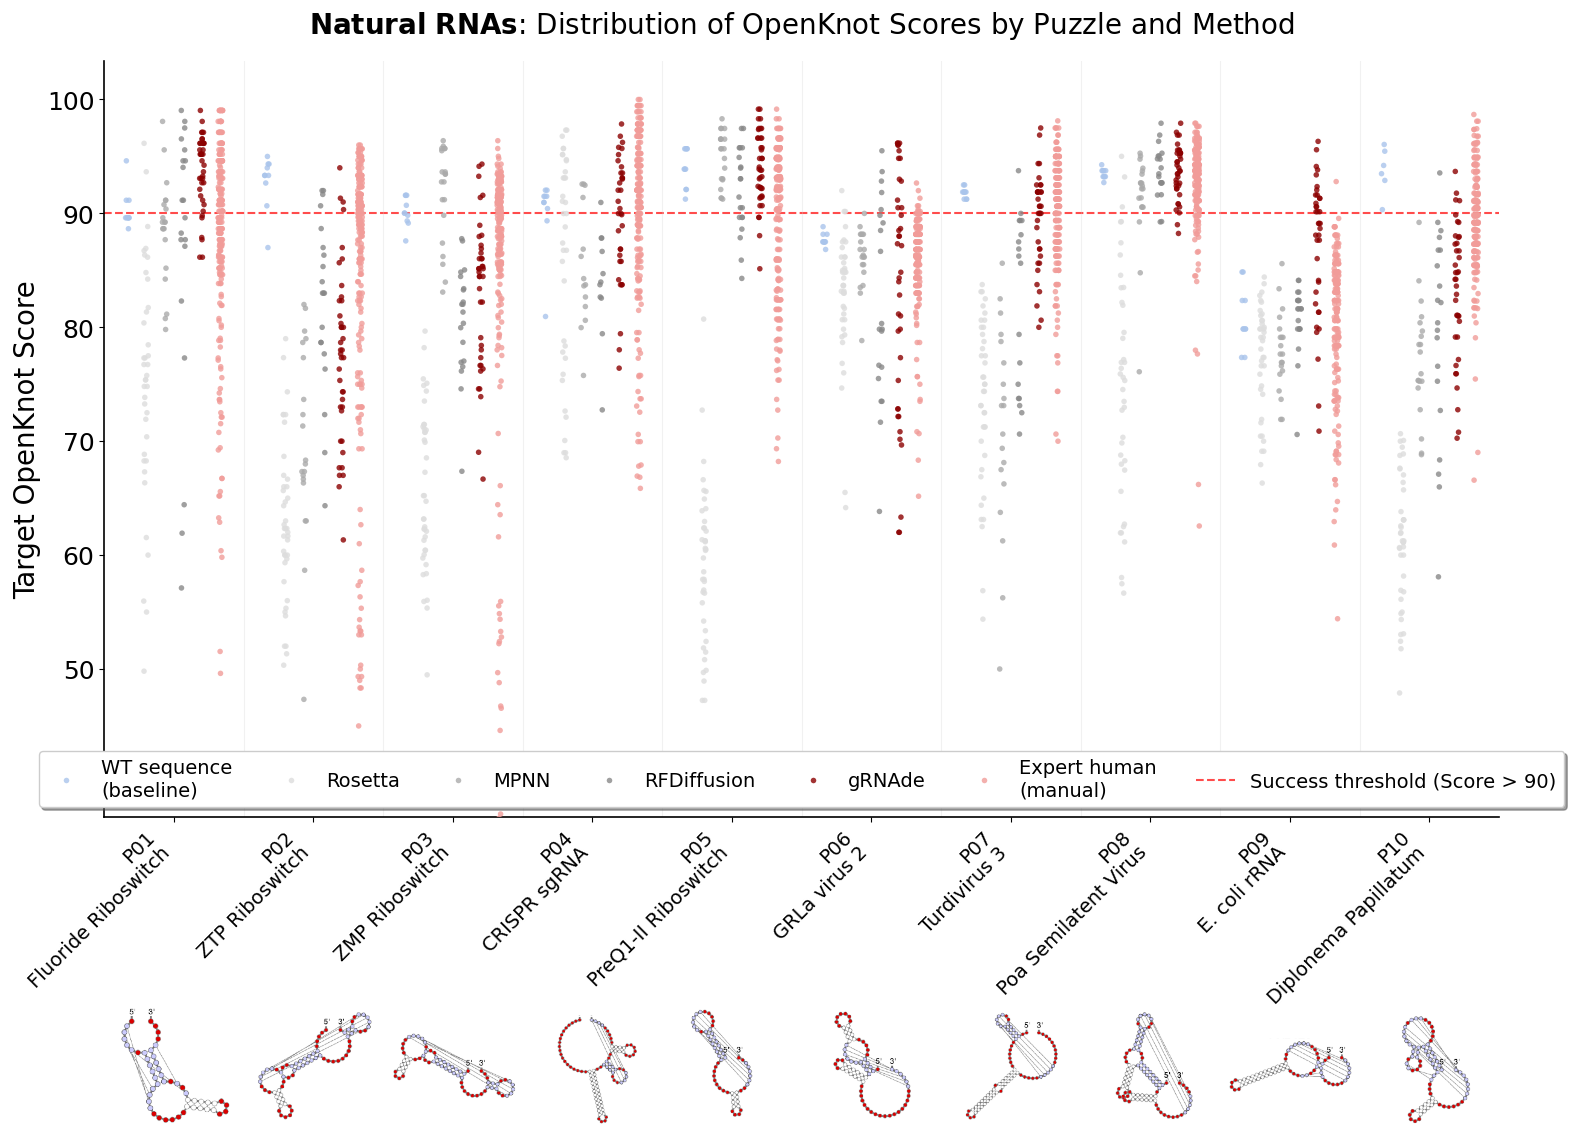

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Define success threshold
success_threshold = 90

# Set custom color scheme
colors = {
    'WT sequence\n(baseline)': '#A9C4EB',
    'Rosetta': '#DDDDDD',
    'MPNN': '#AAAAAA',
    'RFDiffusion': '#888888',
    'gRNAde': '#8B0000',
    'Expert human\n(manual)': '#F19C99',
}

# Define puzzle ranges
natural_puzzles = [f'P{i:02d}' for i in range(1, 11)]  # P01-P10
synthetic_puzzles = [f'P{i:02d}' for i in range(11, 21)]  # P11-P20

# Filter data for each category
df_natural = df[(df['puzzle'].isin(natural_puzzles)) & (df["SN_filter"] == True)]
df_synthetic = df[(df['puzzle'].isin(synthetic_puzzles)) & (df["SN_filter"] == True)]

methods_order = ['WT sequence\n(baseline)', 'Rosetta', 'MPNN', 'RFDiffusion', 'gRNAde', 'Expert human\n(manual)']

# ============================================================================
# FIGURE 1: Natural RNAs Stripplot
# ============================================================================
fig1, ax1 = plt.subplots(1, 1, figsize=(18, 12))

sns.stripplot(data=df_natural, x='puzzle', y='target_openknot_score', hue='method', 
              size=4, alpha=0.8, jitter=True, dodge=True,
              hue_order=methods_order, 
              palette=colors, ax=ax1)

ax1.set_xlabel('', fontsize=14)
ax1.set_ylabel('Target OpenKnot Score', fontsize=20)
ax1.set_title(r"$\bf{" + "Natural \ RNAs" + "}$" + ': Distribution of OpenKnot Scores by Puzzle and Method', 
              fontsize=20, pad=20)

# Get puzzle names for natural RNAs
natural_puzzle_names = []
for puzzle in natural_puzzles:
    if puzzle in df_natural['puzzle'].unique():
        title = df_metadata[df_metadata['Puzzle'] == puzzle]['Title'].iloc[0]
        natural_puzzle_names.append(f"{puzzle}\n{title}")

ax1.set_xticks(range(len(df_natural['puzzle'].unique())))
ax1.set_xticklabels(natural_puzzle_names, rotation=45, ha='right', fontsize=14)

# Add horizontal line at success threshold
ax1.axhline(y=success_threshold, color='red', linestyle='--', alpha=0.7, linewidth=1.5, 
            label=f'Success threshold (Score > {success_threshold})')

# Add vertical lines between puzzles
for i in range(len(df_natural['puzzle'].unique()) - 1):
    ax1.axvline(x=i + 0.5, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.8)

# Style
ax1.set_facecolor('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)

# Add legend
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='lower center', ncol=7,
           frameon=True, fancybox=True, shadow=True, fontsize=14)

ax1.set_ylim(bottom=37)
ax1.tick_params(axis='y', labelsize=18)

# Add puzzle structure images below x-axis ticks
import matplotlib.image as mpimg
for i, puzzle in enumerate(df_natural['puzzle'].unique()):
    img_path = f"figures/round3_viz/{puzzle}.png"
    try:
        # Load PNG image
        img = mpimg.imread(img_path)
        
        # Create OffsetImage with appropriate zoom
        imagebox = OffsetImage(img, zoom=0.2)
        
        # Position the image below the x-axis tick
        # Use axes coordinates for y position to place below the plot
        ab = AnnotationBbox(imagebox, (i, -0.25),
                           frameon=False,
                           box_alignment=(0.5, 1.0),
                           xycoords=('data', 'axes fraction'))
        ax1.add_artist(ab)
    except Exception as e:
        print(f"Warning: Could not load image for {puzzle}: {e}")

# Adjust subplot to make room for images at bottom
plt.subplots_adjust(bottom=0.25)
plt.savefig('figures/okscore_7a_natural_stripplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

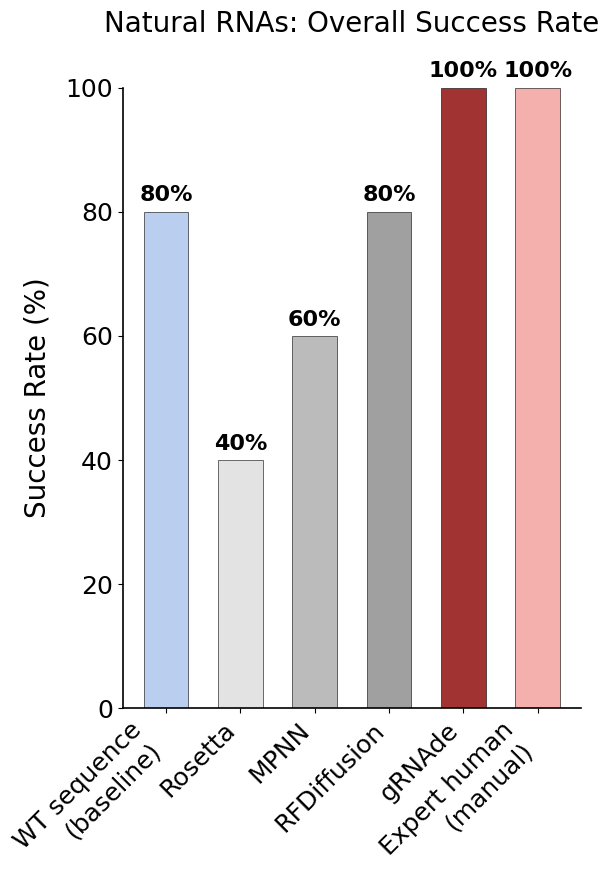

In [17]:
# ============================================================================
# FIGURE 2: Natural RNAs Success Rate Barplot
# ============================================================================
fig2, ax1_bar = plt.subplots(1, 1, figsize=(6, 9))

natural_success = success_natural_r3
natural_rates = [natural_success[method] for method in methods_order]

bars1 = ax1_bar.bar(range(len(methods_order)), natural_rates, 
                    color=[colors[method] for method in methods_order], alpha=0.8, width=0.6,
                    edgecolor='black', linewidth=0.5)
ax1_bar.set_ylim(0, 100)
ax1_bar.set_ylabel('Success Rate (%)', fontsize=20, labelpad=10)
ax1_bar.set_title('Natural RNAs: Overall Success Rate', fontsize=20, pad=40)
ax1_bar.set_xticks(range(len(methods_order)))
ax1_bar.set_xticklabels(methods_order, 
                        rotation=45, ha='right', fontsize=18)
ax1_bar.tick_params(axis='y', labelsize=18)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars1, natural_rates)):
    ax1_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Style
ax1_bar.set_facecolor('white')
ax1_bar.spines['top'].set_visible(False)
ax1_bar.spines['right'].set_visible(False)
ax1_bar.spines['left'].set_linewidth(1.2)
ax1_bar.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('figures/okscore_7a_natural_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

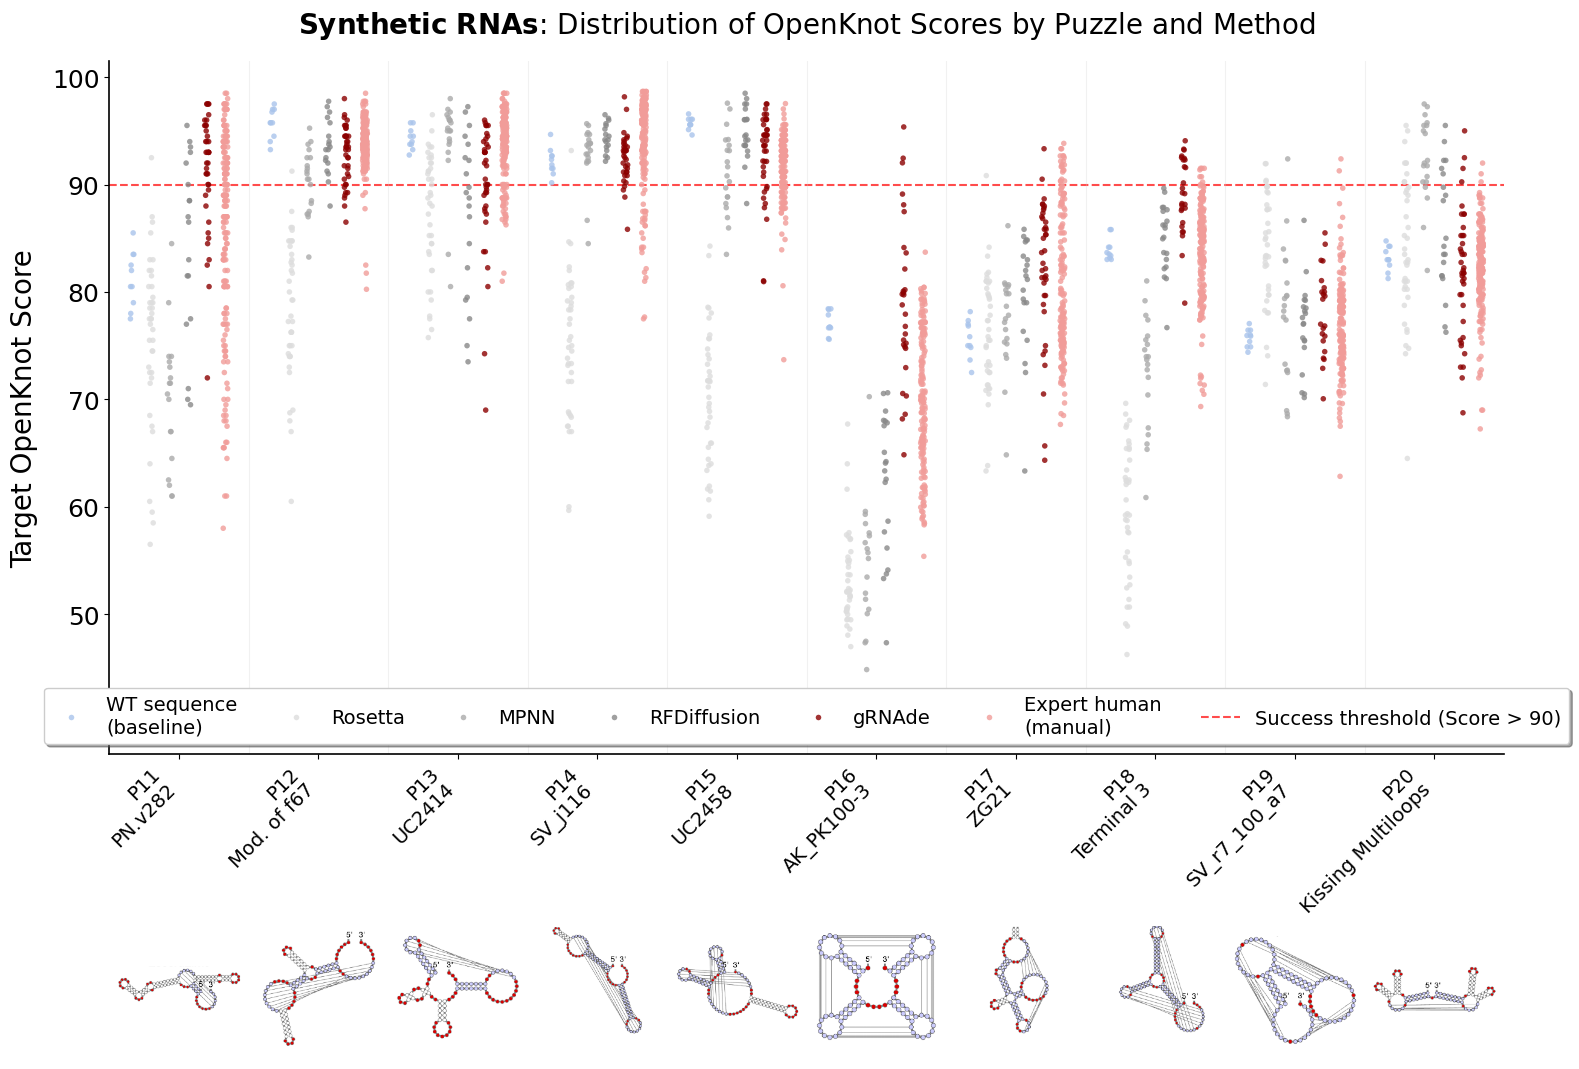

In [26]:
# ============================================================================
# FIGURE 3: Synthetic RNAs Stripplot
# ============================================================================
fig3, ax2 = plt.subplots(1, 1, figsize=(18, 11))

sns.stripplot(data=df_synthetic, x='puzzle', y='target_openknot_score', hue='method', 
              size=4, alpha=0.8, jitter=True, dodge=True,
              hue_order=methods_order,
              palette=colors, ax=ax2)

ax2.set_xlabel('', fontsize=14)
ax2.set_ylabel('Target OpenKnot Score', fontsize=20, labelpad=10)
ax2.set_title(r"$\bf{" + "Synthetic \ RNAs" + "}$" + ': Distribution of OpenKnot Scores by Puzzle and Method', 
              fontsize=20, pad=20)

# Get puzzle names for synthetic RNAs
synthetic_puzzle_names = []
for puzzle in synthetic_puzzles:
    if puzzle in df_synthetic['puzzle'].unique():
        title = df_metadata[df_metadata['Puzzle'] == puzzle]['Title'].iloc[0]
        synthetic_puzzle_names.append(f"{puzzle}\n{title}")

ax2.set_xticks(range(len(df_synthetic['puzzle'].unique())))
ax2.set_xticklabels(synthetic_puzzle_names, rotation=45, ha='right', fontsize=14)
ax2.tick_params(axis='y', labelsize=18)

# Add horizontal line at success threshold
ax2.axhline(y=success_threshold, color='red', linestyle='--', alpha=0.7, linewidth=1.5, 
            label=f'Success threshold (Score > {success_threshold})')

# Add vertical lines between puzzles
for i in range(len(df_synthetic['puzzle'].unique()) - 1):
    ax2.axvline(x=i + 0.5, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.8)

# Style
ax2.set_facecolor('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)

# Add legend
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2, labels2, loc='lower center', ncol=7,
           frameon=True, fancybox=True, shadow=True, fontsize=14)

ax2.set_ylim(bottom=37)

# Add puzzle structure images below x-axis ticks
import matplotlib.image as mpimg
for i, puzzle in enumerate(df_synthetic['puzzle'].unique()):
    img_path = f"figures/round3_viz/{puzzle}.png"
    try:
        # Load PDF image
        img = mpimg.imread(img_path)
        
        # Create OffsetImage with appropriate zoom
        imagebox = OffsetImage(img, zoom=0.2)
        
        # Position the image below the x-axis tick
        # Use axes coordinates for y position to place below the plot
        ab = AnnotationBbox(imagebox, (i, -0.25),
                           frameon=False,
                           box_alignment=(0.5, 1.0),
                           xycoords=('data', 'axes fraction'))
        ax2.add_artist(ab)
    except Exception as e:
        print(f"Warning: Could not load image for {puzzle}: {e}")

# Adjust subplot to make room for images at bottom
plt.subplots_adjust(bottom=0.25)
plt.savefig('figures/okscore_7a_synthetic_stripplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

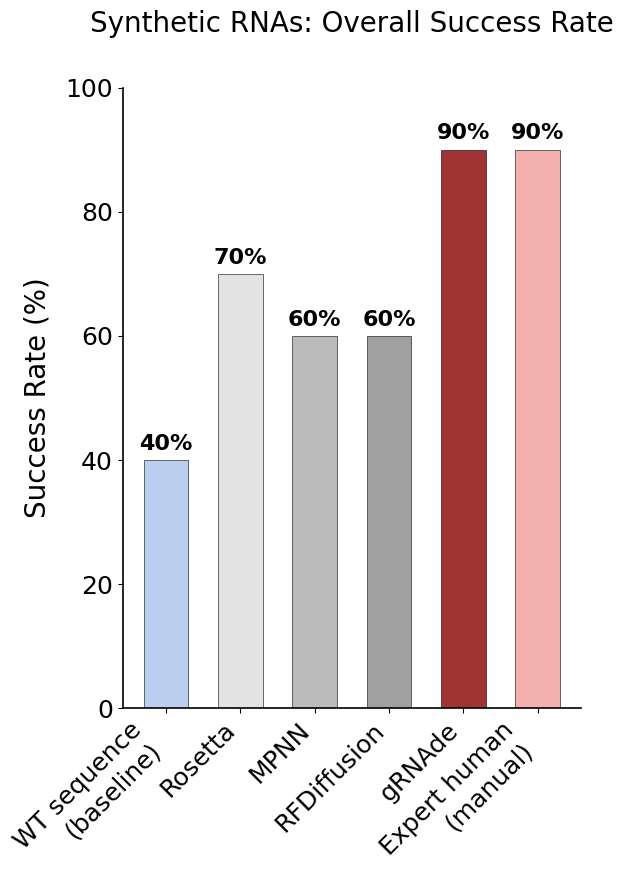

In [27]:
# ============================================================================
# FIGURE 4: Synthetic RNAs Success Rate Barplot
# ============================================================================
fig4, ax2_bar = plt.subplots(1, 1, figsize=(6, 9))

synthetic_success = success_synthetic_r3
synthetic_rates = [synthetic_success[method] for method in methods_order]

bars2 = ax2_bar.bar(range(len(methods_order)), synthetic_rates, 
                    color=[colors[method] for method in methods_order], alpha=0.8, width=0.6,
                    edgecolor='black', linewidth=0.5)
ax2_bar.set_ylim(0, 100)
ax2_bar.set_ylabel('Success Rate (%)', fontsize=20, labelpad=10)
ax2_bar.set_title('Synthetic RNAs: Overall Success Rate', fontsize=20, pad=40)
ax2_bar.set_xticks(range(len(methods_order)))
ax2_bar.set_xticklabels(methods_order, 
                        rotation=45, ha='right', fontsize=18)
ax2_bar.tick_params(axis='y', labelsize=18)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars2, synthetic_rates)):
    ax2_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Style
ax2_bar.set_facecolor('white')
ax2_bar.spines['top'].set_visible(False)
ax2_bar.spines['right'].set_visible(False)
ax2_bar.spines['left'].set_linewidth(1.2)
ax2_bar.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('figures/okscore_7a_synthetic_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

P03
GGGAUACAGGACUGGCGGAUUAGUGGGAAACCACGUGGACUGUAUCCGAAAAAAAGCCGACCGCCUGGGCAUC
.((((((((..(.[[[[[....((((....))))..)..))))))))........(((..]]]]]..)))...


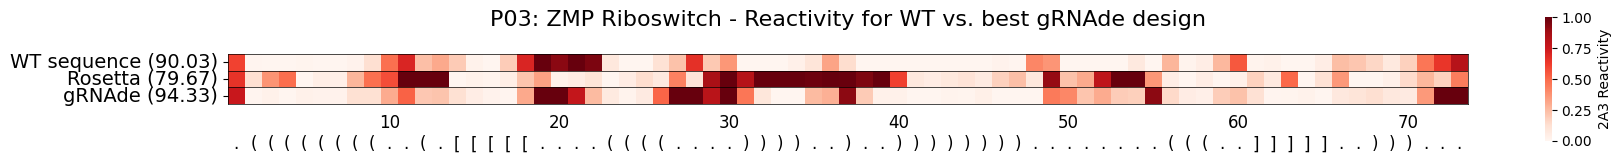

In [18]:
# Set puzzle to analyze
puzzle = "P03"
puzzle_name = df_metadata[df_metadata['Puzzle'] == puzzle]['Title'].values[0]

# get target structure and WT sequence from df_metadata
wt_seq = df_metadata[df_metadata["Puzzle"] == puzzle]["Sequence"].values[0]
wt_struct = df_metadata[df_metadata["Puzzle"] == puzzle]["Dot-bracket"].values[0]

print(puzzle)
print(wt_seq)
print(wt_struct)

# Filter the DataFrame for the current puzzle and "WT" method
filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == "WT sequence\n(baseline)") & (df["SN_filter"] == True)]
assert len(filtered_df) > 0
sub_start = filtered_df.sub_start.values[0] - 1
sub_end = filtered_df.sub_end.values[0]

# sort by 'target_openknot_score' decreasing order
filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

# select the middle WT replicate to get reactivity (instead of best)
middle_idx = len(filtered_df) // 2
row = filtered_df.iloc[middle_idx]
wt_ok_score = row["target_openknot_score"]

# get the reactivity from the row
wt_reactivity_values = []
for i in range(1, 308):
    wt_reactivity_values.append(row[f'reactivity_{i:04d}'])
wt_reactivity_values = np.array(wt_reactivity_values)[row.sub_start - 1 : row.sub_end]

# Collect data for all methods
methods = ["Rosetta", "gRNAde",]  # "Expert human (manual)"
all_data = {f"WT sequence ({wt_ok_score:.2f})": wt_reactivity_values}

# 
top_N = 1

for method in methods:
    # Filter the DataFrame for the current puzzle and method
    filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == method) & (df["SN_filter"] == 1)]
    
    if len(filtered_df) > 0:
        sub_start = filtered_df.sub_start.values[0] - 1
        sub_end = filtered_df.sub_end.values[0]

        # sort by 'target_openknot_score' decreasing order
        filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

        # get the reactivity values for top N designs
        design_ok_score_list = filtered_df["target_openknot_score"].values[:5]
        
        for i, (_, row) in enumerate(filtered_df.head(top_N).iterrows()):
            reactivity_values = []
            for j in range(1, 308):
                reactivity_values.append(row[f'reactivity_{j:04d}'])
            reactivity_array = np.array(reactivity_values)[row.sub_start - 1 : row.sub_end]
            
            all_data[f"{method} ({design_ok_score_list[i]:.2f})"] = reactivity_array

# plot predicted and groundtruth chemical modification
fig, ax = plt.subplots(figsize=(20, 8))

sns.heatmap(
    pd.DataFrame(all_data).transpose(),
    cmap="Reds",
    vmin=0.0,
    vmax=1.0,
    square=True,
    cbar_kws={'shrink': 0.2, 'label': '2A3 Reactivity'},
    ax=ax
)

# Add black outline around the entire heatmap
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_visible(True)

# Add horizontal lines between each row
num_rows = len(all_data)
for i in range(1, num_rows):
    ax.axhline(y=i, color='black', linewidth=0.5, linestyle='-')

plt.title(f"{puzzle}: {puzzle_name} - Reactivity for WT vs. best gRNAde design", fontsize=16, pad=20)

# Set y-ticks fontsize
plt.yticks(fontsize=14)

# Create x-axis labels with position numbers every 10th position and dot-bracket structure
seq_len = len(wt_struct)
x_labels = []
for i in range(seq_len):
    pos = i + 1  # 1-indexed position
    if pos % 10 == 0:
        # Show position number every 10th position
        x_labels.append(f"{pos}\n{wt_struct[i]}")
    else:
        # Show only dot-bracket structure
        x_labels.append(f"\n{wt_struct[i]}")

# Set x-ticks with position numbers and secondary structure
plt.xticks(np.arange(seq_len) + 0.5, x_labels, fontsize=12)
# rotate x-ticks
plt.xticks(rotation=0)
# remove x-tick marks
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=True   # labels along the bottom edge are on
)

plt.savefig('figures/okscore_7a_natural_reactivity_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

P11
CUGCCGACGCCCUGUGUUGAGGCGUGGUGUCGCCUCGAGUCAGUCGUUGAGAUCCGAAGAAGGGUGUACUUCUGACUGAUCGAGCAGAAGUGAGUCGAGG
(((((((((((.(((......))).)))))))[[[[[[((((((((..(((((((......))))...))).))))))))...)))).......]]]]]]


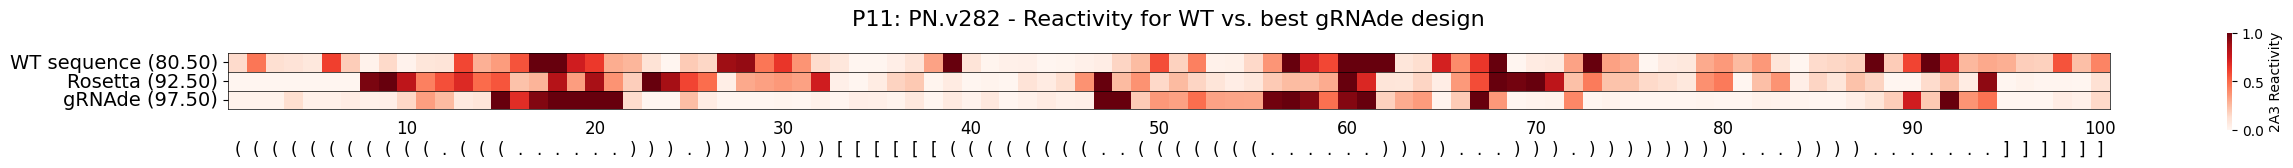

In [28]:
# Set puzzle to analyze
puzzle = "P11"
puzzle_name = df_metadata[df_metadata['Puzzle'] == puzzle]['Title'].values[0]

# get target structure and WT sequence from df_metadata
wt_seq = df_metadata[df_metadata["Puzzle"] == puzzle]["Sequence"].values[0]
wt_struct = df_metadata[df_metadata["Puzzle"] == puzzle]["Dot-bracket"].values[0]

print(puzzle)
print(wt_seq)
print(wt_struct)

# Filter the DataFrame for the current puzzle and "WT" method
filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == "WT sequence\n(baseline)") & (df["SN_filter"] == True)]
assert len(filtered_df) > 0
sub_start = filtered_df.sub_start.values[0] - 1
sub_end = filtered_df.sub_end.values[0]

# sort by 'target_openknot_score' decreasing order
filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

# select the middle WT replicate to get reactivity (instead of best)
middle_idx = len(filtered_df) // 2
row = filtered_df.iloc[middle_idx]
wt_ok_score = row["target_openknot_score"]

# get the reactivity from the row
wt_reactivity_values = []
for i in range(1, 308):
    wt_reactivity_values.append(row[f'reactivity_{i:04d}'])
wt_reactivity_values = np.array(wt_reactivity_values)[row.sub_start - 1 : row.sub_end]

# Collect data for all methods
methods = ["Rosetta", "gRNAde",]  # "Expert human (manual)"
all_data = {f"WT sequence ({wt_ok_score:.2f})": wt_reactivity_values}

# 
top_N = 1

for method in methods:
    # Filter the DataFrame for the current puzzle and method
    filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == method) & (df["SN_filter"] == 1)]
    
    if len(filtered_df) > 0:
        sub_start = filtered_df.sub_start.values[0] - 1
        sub_end = filtered_df.sub_end.values[0]

        # sort by 'target_openknot_score' decreasing order
        filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

        # get the reactivity values for top N designs
        design_ok_score_list = filtered_df["target_openknot_score"].values[:5]
        
        for i, (_, row) in enumerate(filtered_df.head(top_N).iterrows()):
            reactivity_values = []
            for j in range(1, 308):
                reactivity_values.append(row[f'reactivity_{j:04d}'])
            reactivity_array = np.array(reactivity_values)[row.sub_start - 1 : row.sub_end]
            
            all_data[f"{method} ({design_ok_score_list[i]:.2f})"] = reactivity_array

# plot predicted and groundtruth chemical modification
# plt.figure(figsize=(26, 10))
fig, ax = plt.subplots(figsize=(26, 10))

sns.heatmap(
    pd.DataFrame(all_data).transpose(),
    cmap="Reds",
    vmin=0.0,
    vmax=1.0,
    square=True,
    cbar_kws={'shrink': 0.1, 'label': '2A3 Reactivity'},
    ax=ax
)
plt.title(f"{puzzle}: {puzzle_name} - Reactivity for WT vs. best gRNAde design", fontsize=16, pad=20)

# Add black outline around the entire heatmap
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_visible(True)

# Add horizontal lines between each row
num_rows = len(all_data)
for i in range(1, num_rows):
    ax.axhline(y=i, color='black', linewidth=0.5, linestyle='-')

# Set y-ticks fontsize
plt.yticks(fontsize=14)

# Create x-axis labels with position numbers every 10th position and dot-bracket structure
seq_len = len(wt_struct)
x_labels = []
for i in range(seq_len):
    pos = i + 1  # 1-indexed position
    if pos % 10 == 0:
        # Show position number every 10th position
        x_labels.append(f"{pos}\n{wt_struct[i]}")
    else:
        # Show only dot-bracket structure
        x_labels.append(f"\n{wt_struct[i]}")

# Set x-ticks with position numbers and secondary structure
plt.xticks(np.arange(seq_len) + 0.5, x_labels, fontsize=12)
# rotate x-ticks
plt.xticks(rotation=0)
# remove x-tick marks
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=True   # labels along the bottom edge are on
)

plt.tight_layout()

plt.savefig('figures/okscore_7a_synthetic_reactivity_heatmap.pdf', dpi=300, bbox_inches='tight')

plt.show()

P03
GGGAUACAGGACUGGCGGAUUAGUGGGAAACCACGUGGACUGUAUCCGAAAAAAAGCCGACCGCCUGGGCAUC
.((((((((..(.[[[[[....((((....))))..)..))))))))........(((..]]]]]..)))...
P11
CUGCCGACGCCCUGUGUUGAGGCGUGGUGUCGCCUCGAGUCAGUCGUUGAGAUCCGAAGAAGGGUGUACUUCUGACUGAUCGAGCAGAAGUGAGUCGAGG
(((((((((((.(((......))).)))))))[[[[[[((((((((..(((((((......))))...))).))))))))...)))).......]]]]]]


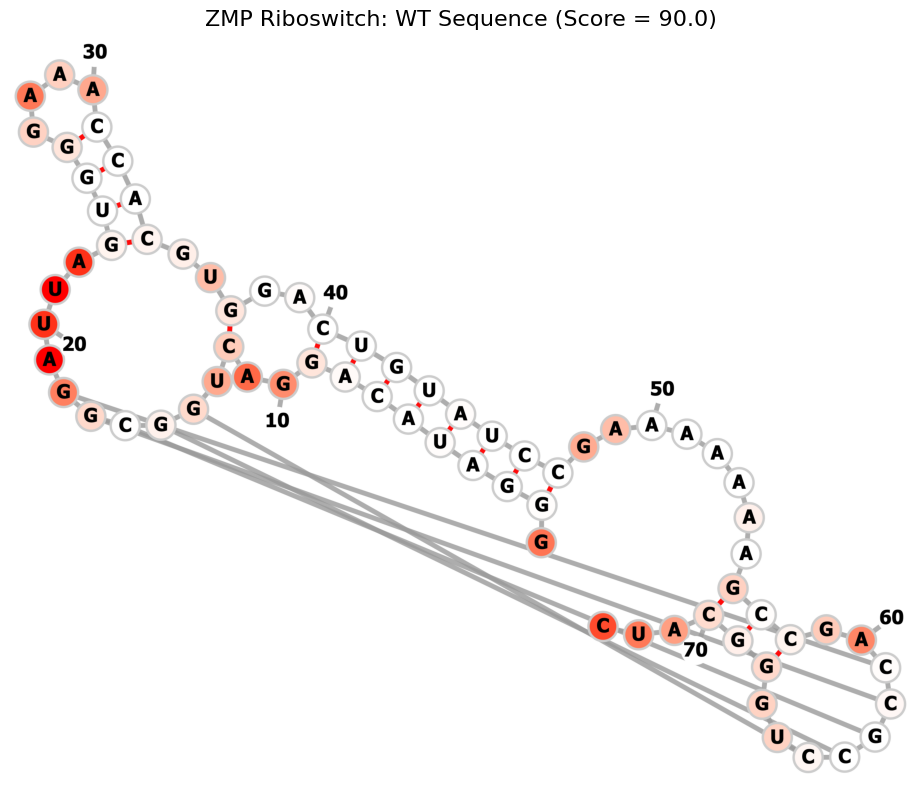

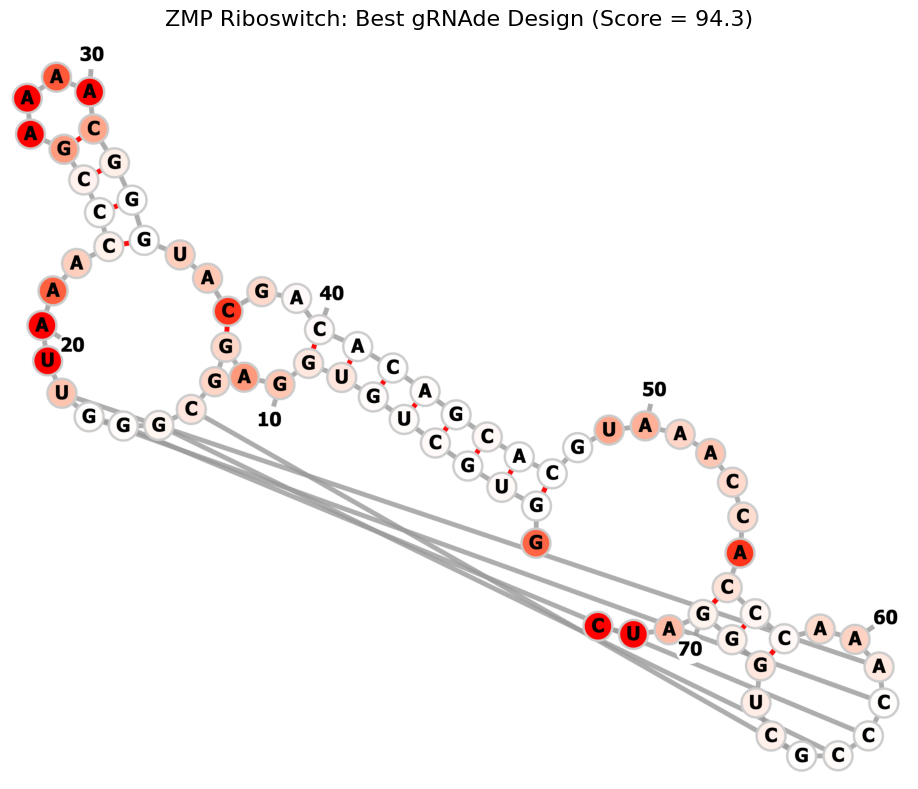

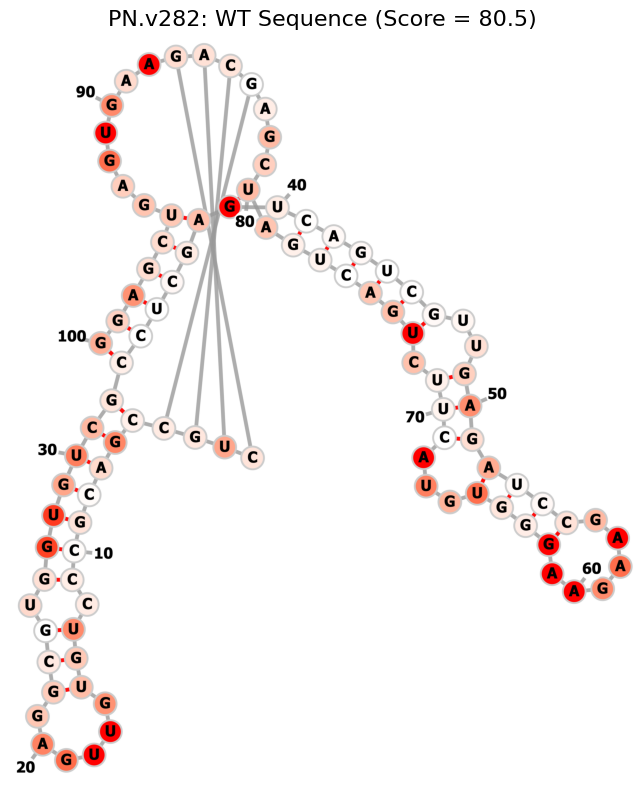

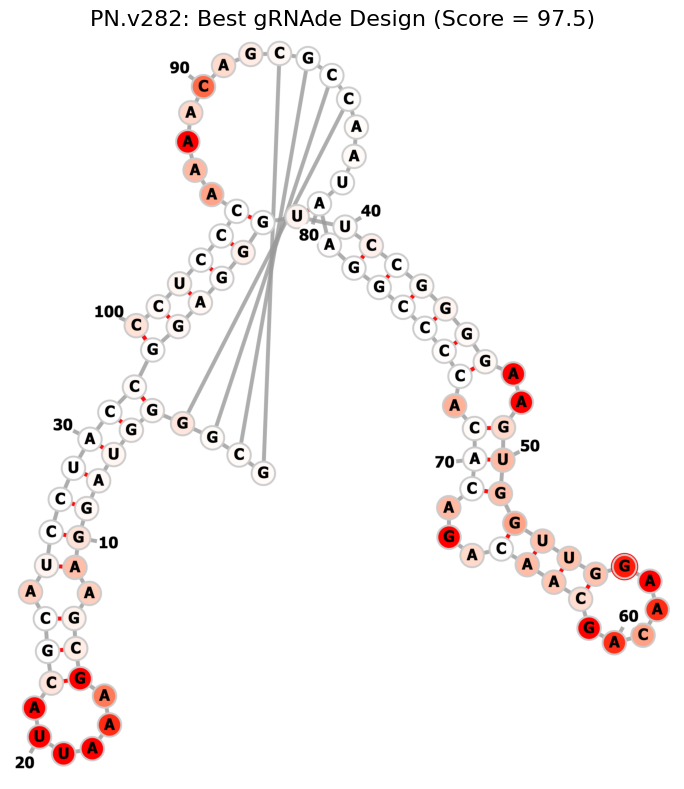

In [23]:
# Store data for both puzzles
puzzle_data = {}
puzzles = ["P03", "P11"]

for puzzle in puzzles:
    puzzle_name = df_metadata[df_metadata['Puzzle'] == puzzle]['Title'].values[0]

    # get target structure and WT sequence from df_metadata
    wt_seq = df_metadata[df_metadata["Puzzle"] == puzzle]["Sequence"].values[0]
    wt_struct = df_metadata[df_metadata["Puzzle"] == puzzle]["Dot-bracket"].values[0]

    print(puzzle)
    print(wt_seq)
    print(wt_struct)

    # Filter the DataFrame for the current puzzle and "WT" method
    filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == "WT sequence\n(baseline)") & (df["SN_filter"] == True)]
    assert len(filtered_df) > 0
    sub_start = filtered_df.sub_start.values[0] - 1
    sub_end = filtered_df.sub_end.values[0]

    # sort by 'target_openknot_score' decreasing order
    filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

    # select the middle WT replicate to get reactivity (instead of best)
    middle_idx = len(filtered_df) // 2
    row = filtered_df.iloc[middle_idx]
    wt_ok_score = row["target_openknot_score"]

    # get the reactivity from the row
    wt_reactivity_values = []
    for i in range(1, 308):
        wt_reactivity_values.append(row[f'reactivity_{i:04d}'])
    wt_reactivity_values = np.array(wt_reactivity_values)[row.sub_start - 1 : row.sub_end]

    # Collect data for all methods
    methods = ["Rosetta", "gRNAde"]  # "Expert human (manual)"
    all_data = {f"WT sequence ({wt_ok_score:.2f})": wt_reactivity_values}

    for method in methods:
        # Filter the DataFrame for the current puzzle and method
        filtered_df = df[(df["puzzle"] == puzzle) & (df["method"] == method) & (df["SN_filter"] == 1)]
        
        if len(filtered_df) > 0:
            sub_start = filtered_df.sub_start.values[0] - 1
            sub_end = filtered_df.sub_end.values[0]

            # sort by 'target_openknot_score' decreasing order
            filtered_df = filtered_df.sort_values(by="target_openknot_score", ascending=False)

            # get the reactivity values for top 5 designs
            design_ok_score_list = filtered_df["target_openknot_score"].values[:5]
            
            for i, (_, row) in enumerate(filtered_df.head(5).iterrows()):
                reactivity_values = []
                for j in range(1, 308):
                    reactivity_values.append(row[f'reactivity_{j:04d}'])
                reactivity_array = np.array(reactivity_values)[row.sub_start - 1 : row.sub_end]
                
                all_data[f"{method} {i+1} ({design_ok_score_list[i]:.2f})"] = reactivity_array

    # Get the best gRNAde design
    filtered_df_grnade = df[(df["puzzle"] == puzzle) & (df["method"] == "gRNAde") & (df["SN_filter"] == True)]
    filtered_df_grnade = filtered_df_grnade.sort_values(by="target_openknot_score", ascending=False)
    best_grnade_row = filtered_df_grnade.iloc[0]
    
    # Store all data for this puzzle
    puzzle_data[puzzle] = {
        'puzzle_name': puzzle_name,
        'wt_ok_score': wt_ok_score,
        'best_grnade_score': best_grnade_row['target_openknot_score'],
        'all_data': all_data
    }

# ============================================================================
# FIGURE 1: P03 WT Sequence
# ============================================================================
puzzle = "P03"
data = puzzle_data[puzzle]

fig1, ax1 = plt.subplots(1, 1, figsize=(12, 8))
wt_best_img = mpimg.imread(f"figures/{puzzle}_wt.png")
ax1.imshow(wt_best_img)
ax1.axis('off')
ax1.set_title(f"{data['puzzle_name']}: WT Sequence (Score = {data['wt_ok_score']:.1f})", 
              fontsize=16, pad=10)

plt.tight_layout()
plt.savefig('figures/P03_wt_sequence.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 2: P03 Best gRNAde Design
# ============================================================================
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 8))
grnade_best_img = mpimg.imread(f"figures/{puzzle}_gRNAde.png")
ax2.imshow(grnade_best_img)
ax2.axis('off')
ax2.set_title(f"{data['puzzle_name']}: Best gRNAde Design (Score = {data['best_grnade_score']:.1f})", 
              fontsize=16, pad=10)

plt.tight_layout()
plt.savefig('figures/P03_grnade_best.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 3: P11 WT Sequence
# ============================================================================
puzzle = "P11"
data = puzzle_data[puzzle]

fig3, ax3 = plt.subplots(1, 1, figsize=(12, 8))
wt_best_img = mpimg.imread(f"figures/{puzzle}_wt.png")
ax3.imshow(wt_best_img)
ax3.axis('off')
ax3.set_title(f"{data['puzzle_name']}: WT Sequence (Score = {data['wt_ok_score']:.1f})", 
              fontsize=16, pad=10)

plt.tight_layout()
plt.savefig('figures/P11_wt_sequence.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 4: P11 Best gRNAde Design
# ============================================================================
fig4, ax4 = plt.subplots(1, 1, figsize=(12, 8))
grnade_best_img = mpimg.imread(f"figures/{puzzle}_gRNAde.png")
ax4.imshow(grnade_best_img)
ax4.axis('off')
ax4.set_title(f"{data['puzzle_name']}: Best gRNAde Design (Score = {data['best_grnade_score']:.1f})", 
              fontsize=16, pad=10)

plt.tight_layout()
plt.savefig('figures/P11_grnade_best.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Round 4 Figures (Supplementary Figure 1)

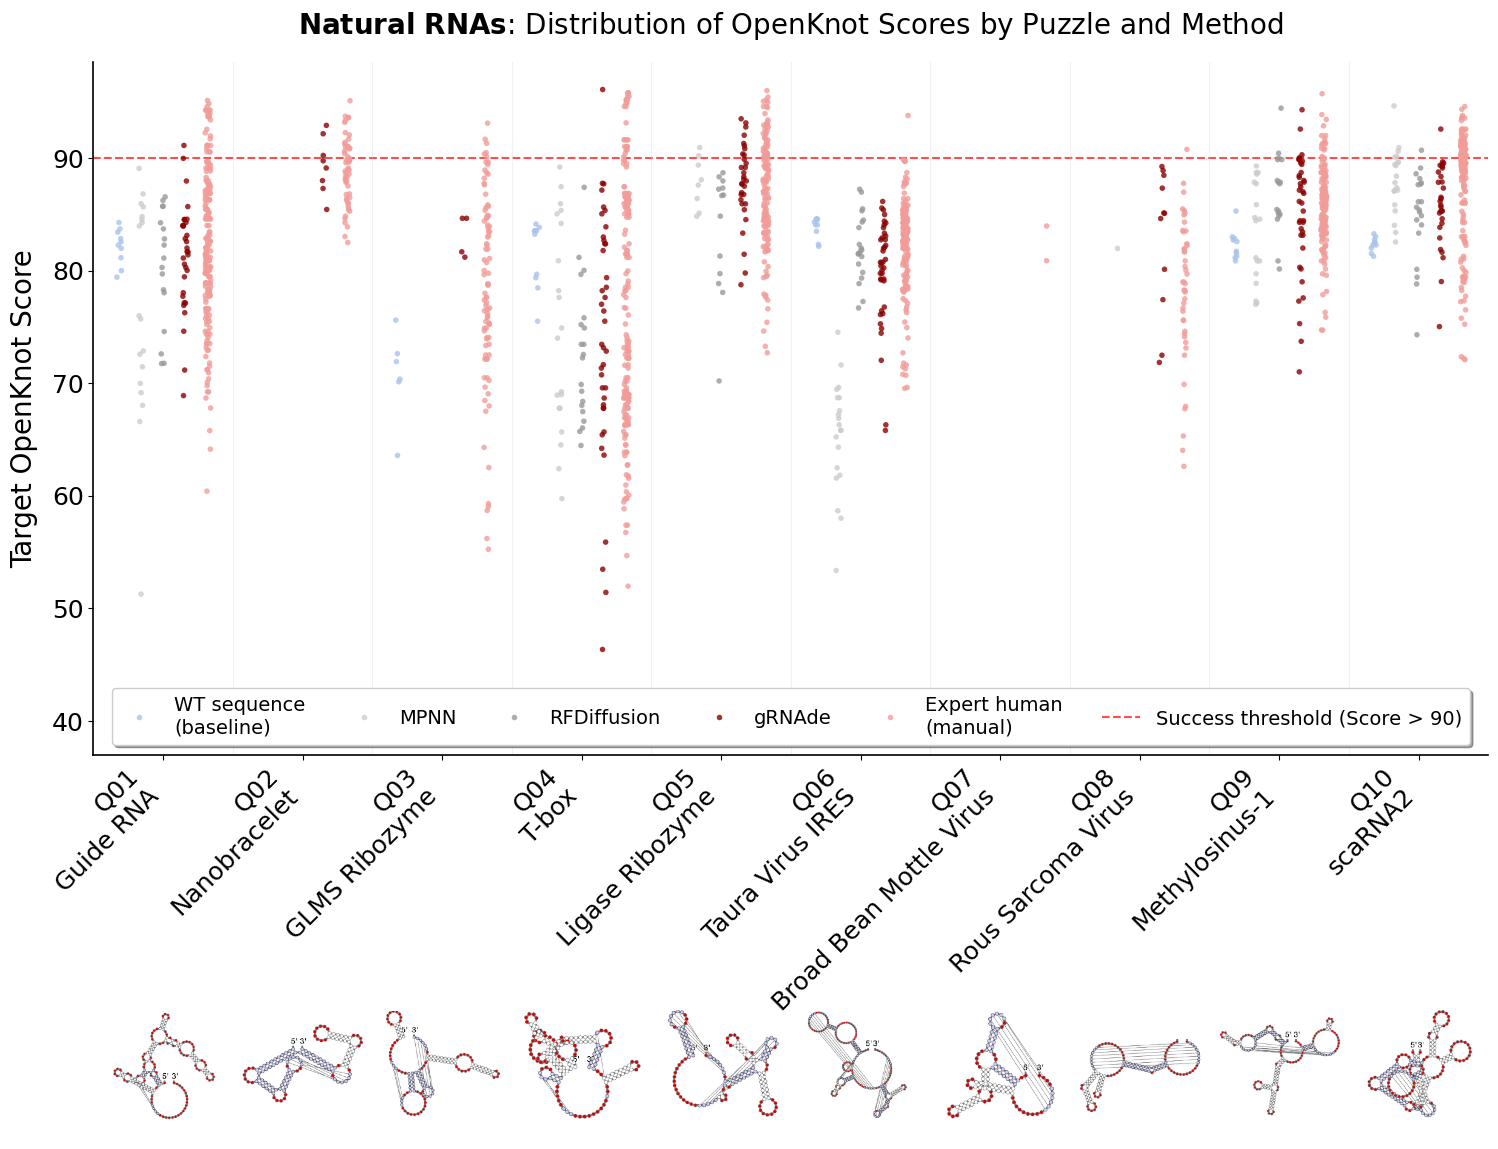

In [ ]:
# Define success threshold
success_threshold = 90

# Set custom color scheme for Round 7b
colors = {
    'WT sequence\n(baseline)': '#A9C4EB',
    # 'Rosetta': '#DDDDDD',
    'MPNN': '#CCCCCC',
    'RFDiffusion': '#999999',
    'gRNAde': '#8B0000',
    'Expert human\n(manual)': '#F19C99',
}

# Define puzzle ranges for Round 7b (Q01-Q20)
natural_puzzles = [f'Q{i:02d}' for i in range(1, 11)]  # Q01-Q10
synthetic_puzzles = [f'Q{i:02d}' for i in range(11, 21)]  # Q11-Q20

# Filter data for each category from df2 (Round 4 = Round 7b)
df_natural = df2[(df2['puzzle'].isin(natural_puzzles)) & (df2["SN_filter"] == True)]
df_synthetic = df2[(df2['puzzle'].isin(synthetic_puzzles)) & (df2["SN_filter"] == True)]

methods_order = ['WT sequence\n(baseline)', 'MPNN', 'RFDiffusion', 'gRNAde', 'Expert human\n(manual)']

# ============================================================================
# FIGURE 1: Natural RNAs Stripplot (Round 7b)
# ============================================================================
fig1, ax1 = plt.subplots(1, 1, figsize=(18, 11))

sns.stripplot(data=df_natural, x='puzzle', y='target_openknot_score', hue='method', 
              size=4, alpha=0.8, jitter=True, dodge=True,
              hue_order=methods_order, 
              palette=colors, ax=ax1)

ax1.set_xlabel('', fontsize=14)
ax1.set_ylabel('Target OpenKnot Score', fontsize=20, labelpad=10)
ax1.set_title(r"$\bf{" + "Natural \ RNAs" + "}$" + ': Distribution of OpenKnot Scores by Puzzle and Method', 
              fontsize=20, pad=20)

# Get puzzle names for natural RNAs
natural_puzzle_names = []
for puzzle in natural_puzzles:
    if puzzle in df_natural['puzzle'].unique():
        title = df_metadata2[df_metadata2['Puzzle'] == puzzle]['Title'].iloc[0]
        natural_puzzle_names.append(f"{puzzle}\n{title}")

ax1.set_xticks(range(len(df_natural['puzzle'].unique())))
ax1.set_xticklabels(natural_puzzle_names, rotation=45, ha='right', fontsize=18)

# Add horizontal line at success threshold
ax1.axhline(y=success_threshold, color='red', linestyle='--', alpha=0.7, linewidth=1.5, 
            label=f'Success threshold (Score > {success_threshold})')

# Add vertical lines between puzzles
for i in range(len(df_natural['puzzle'].unique()) - 1):
    ax1.axvline(x=i + 0.5, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.8)

# Style
ax1.set_facecolor('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)

# Add legend
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='lower center', ncol=7,
           frameon=True, fancybox=True, shadow=True, fontsize=14)

ax1.set_ylim(bottom=37)
ax1.tick_params(axis='y', labelsize=18)

# Add puzzle structure images below x-axis ticks
import matplotlib.image as mpimg
for i, puzzle in enumerate(df_natural['puzzle'].unique()):
    img_path = f"figures/round4_viz/{puzzle}.png"
    try:
        # Load PNG image
        img = mpimg.imread(img_path)
        
        # Create OffsetImage with appropriate zoom
        imagebox = OffsetImage(img, zoom=0.2)
        
        # Position the image below the x-axis tick
        # Use axes coordinates for y position to place below the plot
        ab = AnnotationBbox(imagebox, (i, -0.37),
                           frameon=False,
                           box_alignment=(0.5, 1.0),
                           xycoords=('data', 'axes fraction'))
        ax1.add_artist(ab)
    except Exception as e:
        print(f"Warning: Could not load image for {puzzle}: {e}")

# Adjust subplot to make room for images at bottom
plt.subplots_adjust(bottom=0.25)
plt.savefig('figures/okscore_7b_natural_stripplot.pdf', dpi=300, bbox_inches='tight')
plt.show()


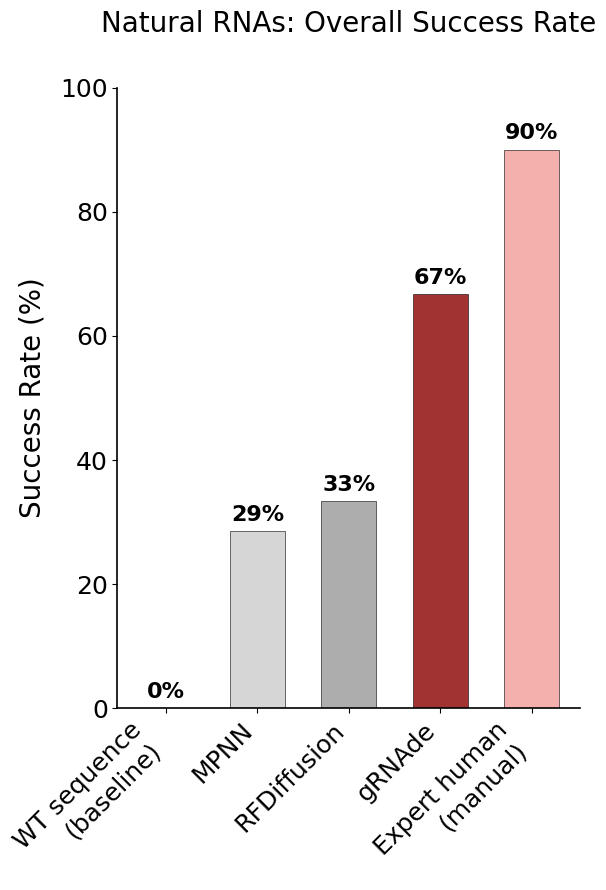

In [30]:
# ============================================================================
# FIGURE 2: Natural RNAs Success Rate Barplot (Round 7b)
# ============================================================================
fig2, ax1_bar = plt.subplots(1, 1, figsize=(6, 9))

natural_success = success_natural_r4
natural_rates = [natural_success[method] for method in methods_order]

bars1 = ax1_bar.bar(range(len(methods_order)), natural_rates, 
                    color=[colors[method] for method in methods_order], alpha=0.8, width=0.6,
                    edgecolor='black', linewidth=0.5)
ax1_bar.set_ylim(0, 100)
ax1_bar.set_ylabel('Success Rate (%)', fontsize=20, labelpad=10)
ax1_bar.set_title('Natural RNAs: Overall Success Rate', fontsize=20, pad=40)
ax1_bar.set_xticks(range(len(methods_order)))
ax1_bar.set_xticklabels(methods_order, 
                        rotation=45, ha='right', fontsize=18)
ax1_bar.tick_params(axis='y', labelsize=18)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars1, natural_rates)):
    ax1_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Style
ax1_bar.set_facecolor('white')
ax1_bar.spines['top'].set_visible(False)
ax1_bar.spines['right'].set_visible(False)
ax1_bar.spines['left'].set_linewidth(1.2)
ax1_bar.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('figures/okscore_7b_natural_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()


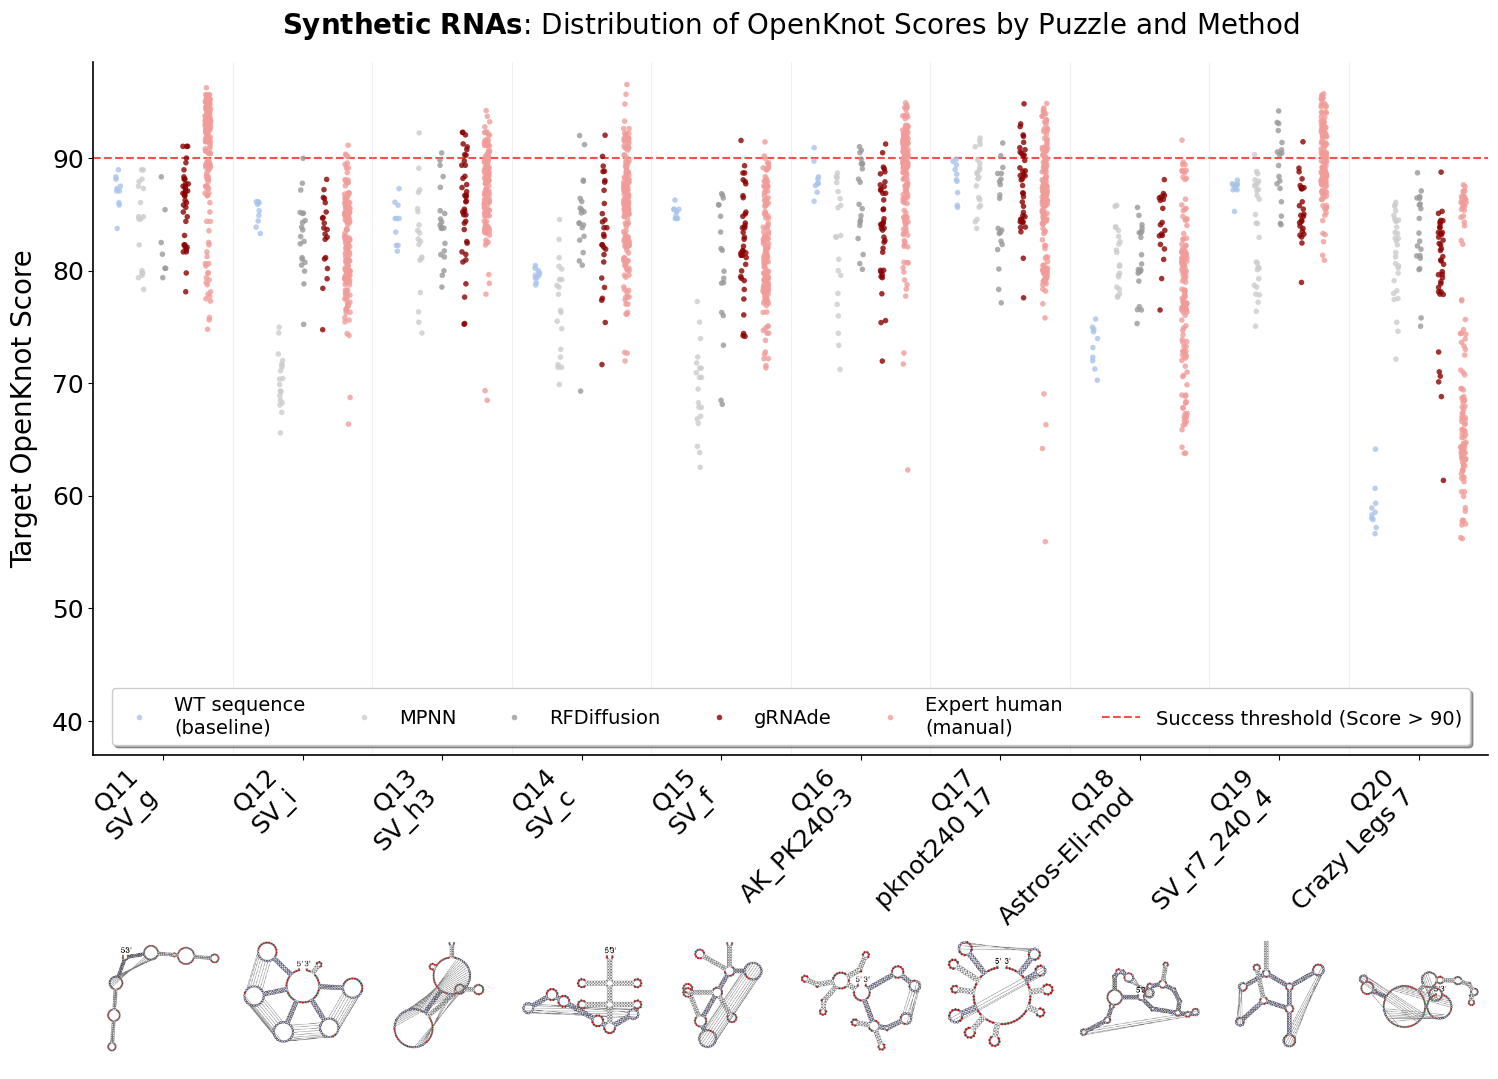

In [31]:
# ============================================================================
# FIGURE 3: Synthetic RNAs Stripplot (Round 7b)
# ============================================================================
fig3, ax2 = plt.subplots(1, 1, figsize=(18, 11))

sns.stripplot(data=df_synthetic, x='puzzle', y='target_openknot_score', hue='method', 
              size=4, alpha=0.8, jitter=True, dodge=True,
              hue_order=methods_order,
              palette=colors, ax=ax2)

ax2.set_xlabel('', fontsize=14)
ax2.set_ylabel('Target OpenKnot Score', fontsize=20, labelpad=10)
ax2.set_title(r"$\bf{" + "Synthetic \ RNAs" + "}$" + ': Distribution of OpenKnot Scores by Puzzle and Method', 
              fontsize=20, pad=20)

# Get puzzle names for synthetic RNAs
synthetic_puzzle_names = []
for puzzle in synthetic_puzzles:
    if puzzle in df_synthetic['puzzle'].unique():
        title = df_metadata2[df_metadata2['Puzzle'] == puzzle]['Title'].iloc[0]
        synthetic_puzzle_names.append(f"{puzzle}\n{title}")

ax2.set_xticks(range(len(df_synthetic['puzzle'].unique())))
ax2.set_xticklabels(synthetic_puzzle_names, rotation=45, ha='right', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)

# Add horizontal line at success threshold
ax2.axhline(y=success_threshold, color='red', linestyle='--', alpha=0.7, linewidth=1.5, 
            label=f'Success threshold (Score > {success_threshold})')

# Add vertical lines between puzzles
for i in range(len(df_synthetic['puzzle'].unique()) - 1):
    ax2.axvline(x=i + 0.5, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.8)

# Style
ax2.set_facecolor('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)

# Add legend
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2, labels2, loc='lower center', ncol=7,
           frameon=True, fancybox=True, shadow=True, fontsize=14)

ax2.set_ylim(bottom=37)

# Add puzzle structure images below x-axis ticks
import matplotlib.image as mpimg
for i, puzzle in enumerate(df_synthetic['puzzle'].unique()):
    img_path = f"figures/round4_viz/{puzzle}.png"
    try:
        # Load PNG image
        img = mpimg.imread(img_path)
        
        # Create OffsetImage with appropriate zoom
        imagebox = OffsetImage(img, zoom=0.2)
        
        # Position the image below the x-axis tick
        # Use axes coordinates for y position to place below the plot
        ab = AnnotationBbox(imagebox, (i, -0.27),
                           frameon=False,
                           box_alignment=(0.5, 1.0),
                           xycoords=('data', 'axes fraction'))
        ax2.add_artist(ab)
    except Exception as e:
        print(f"Warning: Could not load image for {puzzle}: {e}")

# Adjust subplot to make room for images at bottom
plt.subplots_adjust(bottom=0.25)
plt.savefig('figures/okscore_7b_synthetic_stripplot.pdf', dpi=300, bbox_inches='tight')
plt.show()


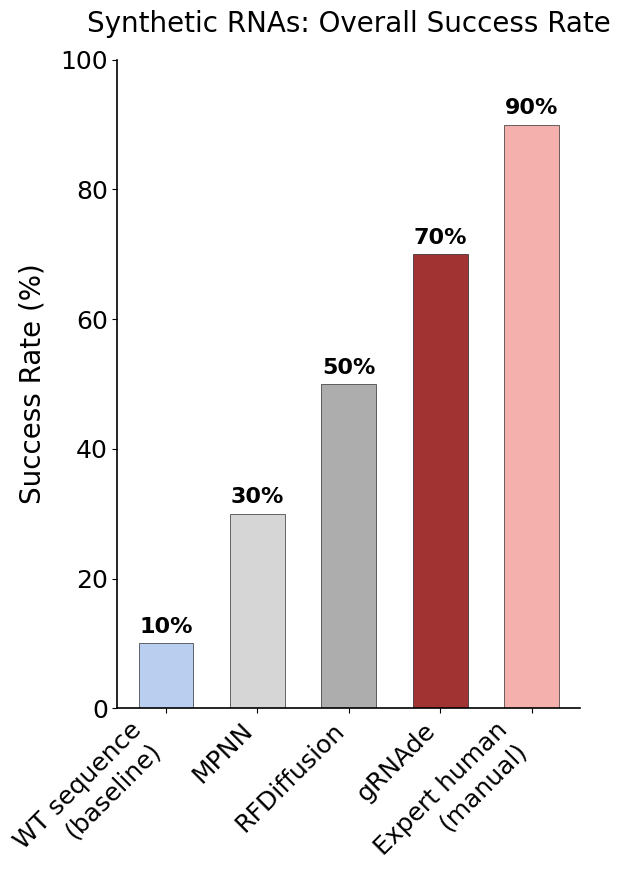

In [32]:
# ============================================================================
# FIGURE 4: Synthetic RNAs Success Rate Barplot (Round 7b)
# ============================================================================
fig4, ax2_bar = plt.subplots(1, 1, figsize=(6, 9))

synthetic_success = success_synthetic_r4
synthetic_rates = [synthetic_success[method] for method in methods_order]

bars2 = ax2_bar.bar(range(len(methods_order)), synthetic_rates, 
                    color=[colors[method] for method in methods_order], alpha=0.8, width=0.6,
                    edgecolor='black', linewidth=0.5)
ax2_bar.set_ylim(0, 100)
ax2_bar.set_ylabel('Success Rate (%)', fontsize=20, labelpad=10)
ax2_bar.set_title('Synthetic RNAs: Overall Success Rate', fontsize=20, pad=20)
ax2_bar.set_xticks(range(len(methods_order)))
ax2_bar.set_xticklabels(methods_order, 
                        rotation=45, ha='right', fontsize=18)
ax2_bar.tick_params(axis='y', labelsize=18)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars2, synthetic_rates)):
    ax2_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.0f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Style
ax2_bar.set_facecolor('white')
ax2_bar.spines['top'].set_visible(False)
ax2_bar.spines['right'].set_visible(False)
ax2_bar.spines['left'].set_linewidth(1.2)
ax2_bar.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('figures/okscore_7b_synthetic_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()
